# __Modelo Base: Desicion Tree Classifier__

## __Importar librerias__

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
from imblearn.under_sampling import NearMiss

from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

## __Cargar datos__

In [6]:
X_cv = pd.read_csv('../out/df/X_cv.csv')
y_cv = pd.read_csv('../out/df/y_cv.csv')
X_cv

,Unnamed: 0,genero_Masculino,jubilado_Si,en_pareja_Si,dependientes_Si,servicio_telefonico_Si,multiples_lineas_No,multiples_lineas_Si,multiples_lineas_sin servicio teleonico,servicio_internet_DSL,...,tipo_contrato_mes a mes,tipo_contrato_un year,facturacion_electronica_Si,metodo_pago_cheque electronico,metodo_pago_cheque por correo,metodo_pago_tarjeta de credito,metodo_pago_transferencia,meses_contrato,cuenta_mensual,cuentas_total
0,134,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,84.30,235.05
1,4974,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,72.0,24.10,1734.65
2,6262,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,3.0,49.15,169.05
3,2718,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,7.0,95.00,655.50
4,3924,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,20.0,19.25,375.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5972,2206,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,45.85,45.85
5973,4189,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,69.0,81.50,5553.25
5974,4304,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,23.0,19.65,436.90
5975,1248,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,7.0,50.30,355.10


## __Analisis de validacion cruzada__

Funcion que calcula e imprime un intervalo de confianza del 95% para una metrica de evaluacion (por defecto, el Recall) obtenida a partir de resultados de validacion cruzada.

Esto ayuda a entender la variabilidad del desempeno del modelo y en que rango se espera que se encuentre la metrica seleccionada.

In [2]:
def cv_score_interval(results, 
                      nombre: str, 
                      score:str='Recall'):
   
    score_mean = np.round(results['test_score'].mean(), 4)
    score_stdev = np.round(results['test_score'].std(), 4)
    lower_b = np.round(score_mean - 2 * score_stdev, 4)
    upper_b = np.round(min(1, score_mean + 2 * score_stdev), 4)
    
    print(f'Recall promedio de {nombre}: {score_mean}')
    print(f'Desviación estándar del Recall de {nombre}: {score_stdev}')
    print(f'El {score} de {nombre} estará entre [{lower_b:.4f},{upper_b:.4f}] con un 95% de confianza')

Aplicar la validacion cruzada al modelo base utilizando los datos _df_

In [5]:
# 6 particiones. Mezcla los datos antes de dividirlos
skf = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)

# instanciar modelo base. Profundidad de 10
baseline_model = DecisionTreeClassifier(max_depth=10, random_state=42)

# Validacion cruzada estratificada. Calcular recall como metrica de desempeno
baseline_cross_val_results = cross_validate(baseline_model, X_cv, y_cv, cv=skf, scoring='recall')

cv_score_interval(
    results=baseline_cross_val_results,
    nombre='Modelo Base',
    score='Recall'
    )

ValueError: Supported target types are: ('binary', 'multiclass'). Got 'multiclass-multioutput' instead.

### _Conjunto X_linear_

In [7]:
robust_scaler_linear = RobustScaler()

# ajustar solo en los datos de entrenamiento
X_linear_cv[var_num_scaled] = robust_scaler_linear.fit_transform(X_linear_cv[var_num])

# calcular los valores escalados en todos los split 
# basandose en los parametros aprendidos solo en el conjunto de entrenamiento
X_linear_train[var_num_scaled] = robust_scaler_linear.transform(X_linear_train[var_num])
X_linear_val[var_num_scaled] = robust_scaler_linear.transform(X_linear_val[var_num])
X_linear_test[var_num_scaled] = robust_scaler_linear.transform(X_linear_test[var_num])

# eliminar variables numericas originales dejando solo las escaladas
X_linear_cv.drop(var_num, axis=1, inplace=True)
X_linear_train.drop(var_num, axis=1, inplace=True)
X_linear_val.drop(var_num, axis=1, inplace=True)
X_linear_test.drop(var_num, axis=1, inplace=True)

X_linear_cv.head()

,genero_Masculino,jubilado_Si,en_pareja_Si,dependientes_Si,servicio_telefonico_Si,multiples_lineas_Si,multiples_lineas_sin servicio teleonico,servicio_internet_Fibra_optica,No_servicio_internet,seguridad_online_Si,...,streaming_peliculas_Si,tipo_contrato_mes a mes,tipo_contrato_un year,facturacion_electronica_Si,metodo_pago_cheque por correo,metodo_pago_tarjeta de credito,metodo_pago_transferencia,scaler_meses_contrato,scaler_cuenta_mensual,scaler_cuentas_total
134,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,-0.553191,0.256198,-0.340435
4974,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.914894,-0.849403,0.101150
6262,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,-0.553191,-0.389348,-0.359870
2718,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.468085,0.452709,-0.216626
3924,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-0.191489,-0.938476,-0.299150


## __Balanceo del dataset__

Visualizar la proporcion de clientes que cancelan y no cancelan

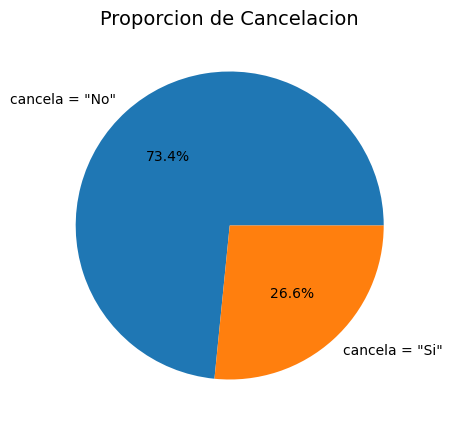

In [9]:
# agrupar las clases de cancelacion y generar un df con los mismos
cancelan = df.groupby('cancelacion')['cancelacion'].value_counts()
cancelan = pd.DataFrame(cancelan)

# grafico de pie
fig, ax = plt.subplots(figsize=(6,5))
ax = plt.pie(
    data=cancelan,
    x=cancelan['count'],
    labels=['cancela = "No"', 'cancela = "Si"'],
    autopct='%1.1f%%'
)
plt.title('Proporcion de Cancelacion', fontsize = 14)
plt.show()

> La distribucion de clases esta desbalanceada: cerca del 74% de los registros corresponden a clientes que no han abandonado la empresa. Tal desbalance puede sesgar el modelo durante el entrenamiento dificultando su capacidad para aprender correctamente

Vamos a aplicar una estrategia de balanceo sobre los datos de entrenamiento para evitar el Data Leakage. La tecnica de undersampling a utilizar es NearMiss que selecciona los ejemplos mas relevantes de la clase mayoritaria lo que contribuye a mejorar al modelo a detectar cancelaciones.

In [13]:
# instanciamos el balanceador
undersampler = NearMiss(version=3)

### _Conjunto X_

In [14]:
# aplicar balanceador sonbre los datos de df
X_cv, y_cv = undersampler.fit_resample(X_cv, y_cv)
X_train, y_train = undersampler.fit_resample(X_train, y_train)

# verificar proporcion en y de entrenamiento
y_cv.value_counts()

cancelacion
0    1589
1    1589
Name: count, dtype: int64

In [15]:
y_train.value_counts()

cancelacion
0    1430
1    1430
Name: count, dtype: int64

### _Conjunto X_linear_

In [ ]:
# Aplicar balanceador sobre los datos de entrenamiento de df_linear
X_linear_cv, y_linear_cv = undersampler.fit_resample(X_linear_cv, y_linear_cv)
X_linear_train, y_linear_train = undersampler.fit_resample(X_linear_train, y_linear_train)

# verificar proporcion en y de entrenamiento
y_linear_cv.value_counts()

cancelacion
0    1589
1    1589
Name: count, dtype: int64

### _Conjunto X_scale_

In [18]:
# aplicar blanceador sobre los datos de entrenamiento de df_scale
X_scale_cv, y_scale_cv = undersampler.fit_resample(X_scale_cv, y_scale_cv)
X_scale_train, y_scale_train = undersampler.fit_resample(X_scale_train, y_scale_train)

# verificar proporcion en y
y_scale_cv.value_counts()

cancelacion
0    1589
1    1589
Name: count, dtype: int64